In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.eda_utils import (
    calculate_loss_ratio,
    calculate_margin,
    missing_values_table
)

In [10]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from src.data_loader import load_data

df = load_data("../data/raw/MachineLearningRating_v3.txt")
df.head()

c:\Users\Alienware\Desktop\kaim works\insurance-risk-analytics\src\data_loader.py:4: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [11]:
df.info()

df.describe()

df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

,TransactionMonth,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,...,CrossBorder,TermFrequency,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType
count,1000098,1000098,1000098,1000098,1000098,854137,959866,991839,990562,1000098,...,698,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098
unique,23,4,6,5,1,11,3,3,3,1,...,1,2,13,28,22,14,5,4,1,1
top,2015-08-01 00:00:00,,Individual,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,No,Monthly,No excess,Passenger Liability,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant
freq,106747,895210,911929,933555,1000098,260811,597938,986208,940990,1000098,...,698,999554,791235,104158,104183,824124,828125,915028,1000098,1000098


In [12]:
missing_values_table(df)

NumberOfVehiclesInFleet     100.000000
CrossBorder                  99.930207
CustomValueEstimate          77.956560
Rebuilt                      64.183810
Converted                    64.183810
WrittenOff                   64.183810
NewVehicle                   15.327998
Bank                         14.594670
AccountType                   4.022806
Gender                        0.953507
MaritalStatus                 0.825819
VehicleType                   0.055195
make                          0.055195
mmcode                        0.055195
Model                         0.055195
Cylinders                     0.055195
bodytype                      0.055195
kilowatts                     0.055195
NumberOfDoors                 0.055195
VehicleIntroDate              0.055195
cubiccapacity                 0.055195
CapitalOutstanding            0.000200
SubCrestaZone                 0.000000
ItemType                      0.000000
Province                      0.000000
Country                  

In [19]:
df = df.drop(columns=[
    "CustomValueEstimate",
    "Rebuilt",
    "Converted",
    "WrittenOff"
])

In [20]:
df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

In [27]:
df[num_cols].dtypes
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [30]:
df[num_cols].describe()

,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06
mean,6.190550e+01,6.486119e+01
std,2.302845e+02,2.384075e+03
min,-7.825768e+02,-1.200241e+04
25%,0.000000e+00,0.000000e+00
50%,2.178333e+00,0.000000e+00
75%,2.192982e+01,0.000000e+00
max,6.528260e+04,3.930921e+05


In [34]:
(df[num_cols] == 0).sum()

TotalPremium    381634
TotalClaims     997305
dtype: int64

c:\Users\Alienware\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


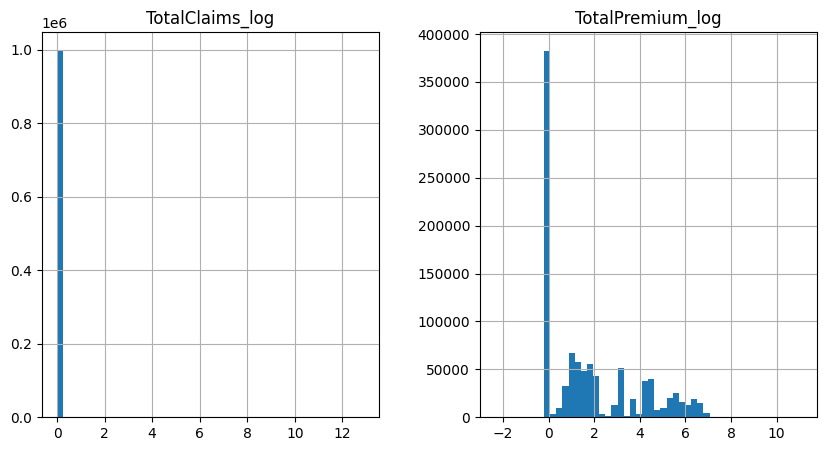

In [35]:
import numpy as np

df["TotalClaims_log"] = np.log1p(df["TotalClaims"])
df["TotalPremium_log"] = np.log1p(df["TotalPremium"])

df[["TotalClaims_log", "TotalPremium_log"]].hist(figsize=(10,5), bins=50)
plt.show()

In [36]:
print(df[num_cols].head())
print(df[num_cols].describe())
print(df[num_cols].isnull().sum())

   TotalPremium  TotalClaims
0     21.929825          0.0
1     21.929825          0.0
2      0.000000          0.0
3    512.848070          0.0
4      0.000000          0.0
       TotalPremium   TotalClaims
count  1.000098e+06  1.000098e+06
mean   6.190550e+01  6.486119e+01
std    2.302845e+02  2.384075e+03
min   -7.825768e+02 -1.200241e+04
25%    0.000000e+00  0.000000e+00
50%    2.178333e+00  0.000000e+00
75%    2.192982e+01  0.000000e+00
max    6.528260e+04  3.930921e+05
TotalPremium    0
TotalClaims     0
dtype: int64
